In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
deslizamientos = pd.read_csv('../data/datos_simma.csv')

In [6]:
deslizamientos["Departamento"].unique().size

25

In [16]:
deslizamientos.head()

,Tipo_Movimiento,Fecha,Departamento,Municipio,Altura_msnm,Latitud,Longitud
0,Deslizamiento,02/03/2025,BOYACÁ,SOMONDOCO,1.642,4.976953,-73.442894
1,Deslizamiento,03/09/2023,BOYACÁ,RONDÓN,1.820,5.359969,-73.199800
2,Deslizamiento,26/06/2023,BOYACÁ,SANTANA,1.607,6.039606,-73.492428
3,Deslizamiento,25/05/2023,BOYACÁ,SIACHOQUE,3.167,5.494425,-73.220261
4,Deslizamiento,24/05/2023,BOYACÁ,NaN,1.918,5.916550,-73.493317


In [19]:
# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [22]:
# CONVERTIR FECHA
deslizamientos['Fecha'] = pd.to_datetime(deslizamientos['Fecha'], format='%d/%m/%Y')
deslizamientos['Año'] = deslizamientos['Fecha'].dt.year
deslizamientos['Mes'] = deslizamientos['Fecha'].dt.month
deslizamientos['Día_Semana'] = deslizamientos['Fecha'].dt.day_name()

In [23]:
# INFORMACIÓN GENERAL
print(f"• Total de registros: {len(deslizamientos):,}")
print(f"• Columnas: {list(deslizamientos.columns)}")
print(f"• Período: {deslizamientos['Fecha'].min()} - {deslizamientos['Fecha'].max()}")
print("\nDATOS FALTANTES:")
missing = deslizamientos.isnull().sum()
for col, count in missing.items():
    if count > 0:
        pct = (count/len(deslizamientos))*100
        print(f"• {col}: {count} ({pct:.1f}%)")

• Total de registros: 5,631
• Columnas: ['Tipo_Movimiento', 'Fecha', 'Departamento', 'Municipio', 'Altura_msnm', 'Latitud', 'Longitud', 'Año', 'Mes', 'Día_Semana']
• Período: 2000-10-09 00:00:00 - 2025-03-02 00:00:00

DATOS FALTANTES:
• Municipio: 441 (7.8%)


In [24]:
# ESTADÍSTICAS DESCRIPTIVAS
print("\n ESTADÍSTICAS GEOGRÁFICAS:")
print(f"• Altura promedio: {deslizamientos['Altura_msnm'].mean():.0f} msnm")
print(f"• Altura máxima: {deslizamientos['Altura_msnm'].max():.0f} msnm")
print(f"• Altura mínima: {deslizamientos['Altura_msnm'].min():.0f} msnm")
print(f"• Departamentos únicos: {deslizamientos['Departamento'].nunique()}")
print(f"• Municipios únicos: {deslizamientos['Municipio'].nunique()}")


 ESTADÍSTICAS GEOGRÁFICAS:
• Altura promedio: 3 msnm
• Altura máxima: 11 msnm
• Altura mínima: 0 msnm
• Departamentos únicos: 25
• Municipios únicos: 469


In [25]:
fig = plt.figure(figsize=(20, 15))

<Figure size 2000x1500 with 0 Axes>

([<matplotlib.axis.XTick at 0x1aa94ae2120>,
 [Text(0, 0, 'BOYACÁ'),
  Text(1, 0, 'CAUCA'),
  Text(2, 0, 'CUNDINAMARCA'),
  Text(3, 0, 'ANTIOQUIA'),
  Text(4, 0, 'VALLE DEL CAUCA'),
  Text(5, 0, 'NARIÑO'),
  Text(6, 0, 'CALDAS'),
  Text(7, 0, 'TOLIMA'),
  Text(8, 0, 'SANTANDER'),
  Text(9, 0, 'HUILA')])

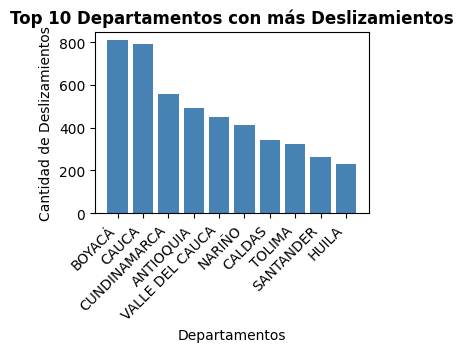

In [27]:
# 1. DISTRIBUCIÓN POR DEPARTAMENTO
plt.subplot(3, 3, 1)
dept_counts = deslizamientos['Departamento'].value_counts().head(10)
plt.bar(range(len(dept_counts)), dept_counts.values, color='steelblue')
plt.title('Top 10 Departamentos con más Deslizamientos', fontweight='bold')
plt.xlabel('Departamentos')
plt.ylabel('Cantidad de Deslizamientos')
plt.xticks(range(len(dept_counts)), dept_counts.index, rotation=45, ha='right')

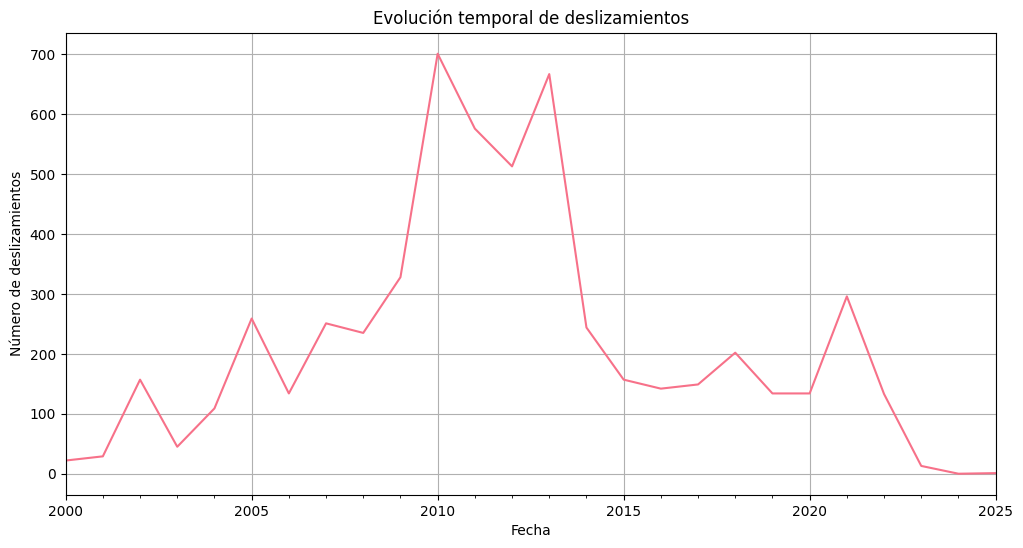

In [ ]:
# 2. EVOLUCIÓN TEMPORAL
# deslizamientos por año
evolucion = deslizamientos.resample('Y', on='Fecha').size()

plt.figure(figsize=(12,6))
evolucion.plot()
plt.title("Evolución temporal de deslizamientos por año", fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Número de deslizamientos")
plt.grid(True)
plt.show()

Text(0, 0.5, 'Cantidad')

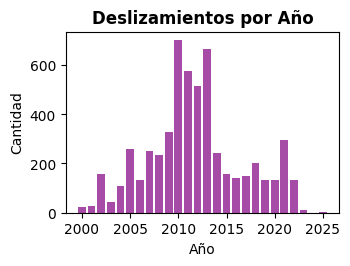

In [43]:
plt.subplot(3, 3, 5)
yearly_counts = deslizamientos['Fecha'].dt.year.value_counts().sort_index()
plt.bar(yearly_counts.index, yearly_counts.values, color='purple', alpha=0.7)
plt.title('Deslizamientos por Año', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Cantidad')

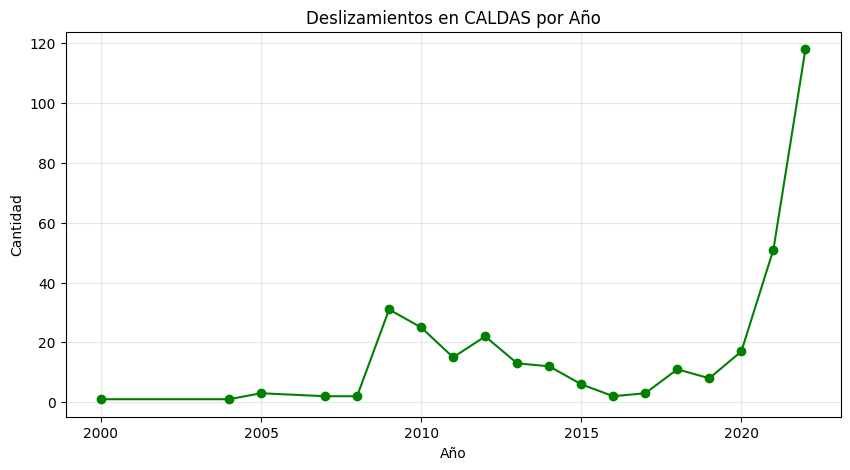

In [31]:
#Caldas por año:
caldas = deslizamientos[deslizamientos["Departamento"].str.contains("CALDAS", case=False, na=False)]
deslizamientos_caldas_ano = caldas.groupby(caldas["Fecha"].dt.year).size()

plt.figure(figsize=(10,5))
deslizamientos_caldas_ano.plot(marker='o', color='green')
plt.title('Deslizamientos en CALDAS por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.grid(True, alpha=0.3)
plt.show()

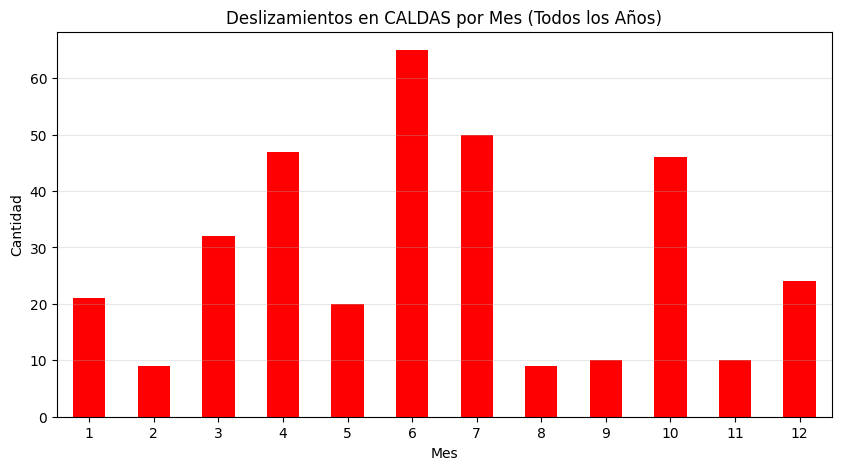

In [35]:
#caldas por mes:
deslizamientos_caldas_mes = caldas.groupby(caldas["Fecha"].dt.month).size()

plt.figure(figsize=(10,5))
deslizamientos_caldas_mes.plot(kind='bar', color='red')
plt.title('Deslizamientos en CALDAS por Mes (Todos los Años)')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


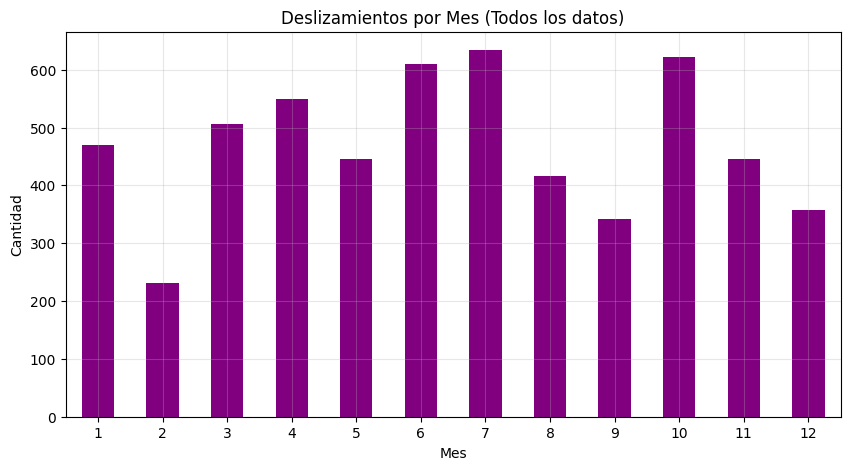


 Meses con más deslizamientos (todos los datos):
Mes 7: 634 deslizamientos.
Mes 10: 622 deslizamientos.
Mes 6: 610 deslizamientos.


In [ ]:
deslizamientos_por_mes = deslizamientos.groupby(deslizamientos["Fecha"].dt.month).size()

plt.figure(figsize=(10,5))
deslizamientos_por_mes.plot(kind='bar', color='purple')
plt.title('Deslizamientos por Mes (Todos los datos)')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

# Resultado
top_3 = deslizamientos_por_mes.sort_values(ascending=False).head(3)
print("\n Meses con más deslizamientos (todos los datos):")
for mes, cnt in top_3.items():
    print(f"Mes {mes}: {cnt} deslizamientos.")


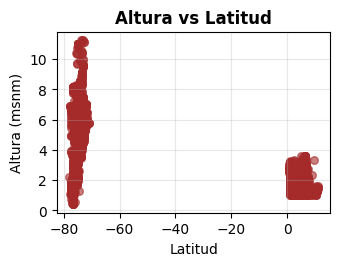

In [ ]:
#RELACIÓN ALTURA vs LATITUD:
#este no sé pa que pueda servir, pero lo dejo por si acaso
plt.subplot(3, 3, 6)
plt.scatter(deslizamientos['Latitud'], deslizamientos['Altura_msnm'], alpha=0.6, color='brown', s=30)
plt.title('Altura vs Latitud', fontweight='bold')
plt.xlabel('Latitud')
plt.ylabel('Altura (msnm)')
plt.grid(True, alpha=0.3)

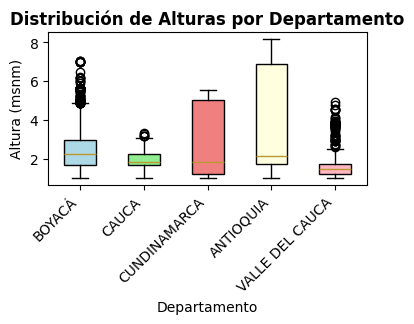

In [ ]:
#ALTURAS POR DEPARTAMENTO
#esta gráfica no la entiendo
plt.subplot(3, 3, 9)
top_depts = deslizamientos['Departamento'].value_counts().head(5).index
df_top = deslizamientos[deslizamientos['Departamento'].isin(top_depts)]
bp = plt.boxplot([df_top[df_top['Departamento'] == dept]['Altura_msnm'].values 
                  for dept in top_depts], 
                 labels=top_depts, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Distribución de Alturas por Departamento', fontweight='bold')
plt.xlabel('Departamento')
plt.ylabel('Altura (msnm)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout(pad=3.0)
plt.show()